**1. Data import and setup**

In [ ]:
import pandas as pd
import numpy as np
# import csv using pandas
df = pd.read_csv('social_media_engagement_5000.csv')
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


**B. Check data types**

In [ ]:
df.dtypes

,0
user_id,Int64
age,Float64
gender,string[python]
country,string[python]
post_id,Int64
post_type,string[python]
post_category,string[python]
likes,Float64
comments,Float64
shares,Float64


**C. Convert dates column to datetime**

In [ ]:
df['posted_at'] = pd.to_datetime(df['posted_at'], errors='coerce')
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


**2. Imputation -- Data cleaning**
           a. cleaning missing values

In [ ]:
# Detecting missing value
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
# Filling numerical columns with average
df["age"]= df["age"].fillna(df["age"].mean())
df["likes"]= df["likes"].fillna(df["likes"].mean())
df["comments"]= df["comments"].fillna(df["comments"].mean())
df["shares"]= df["shares"].fillna(df["shares"].mean())
df.isnull().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
# count the values of gender and sentiment using value count
df["gender"].value_counts()


,count
gender,
Male,1699
Other,1581
Female,1570


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,2363
neutral,1527
negative,960


In [ ]:
# Filling categorical column with own category
df["gender"] = df["gender"].fillna("unknown")
df["sentiment"] = df["sentiment"].fillna("unknown")
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.00000,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.00000,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.00000,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.00000,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.00000,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.00000,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.00000,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.00000,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


**b. Duplicates handling - identify and remove duplicates**

In [ ]:
df.duplicated("user_id").sum()

np.int64(138)

In [ ]:
df = df.drop_duplicates("user_id")

**C. Data Formatting**

In [ ]:
# fix incorrect datatype
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4862 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4862 non-null   Int64         
 1   age               4862 non-null   Float64       
 2   gender            4862 non-null   string        
 3   country           4862 non-null   string        
 4   post_id           4862 non-null   Int64         
 5   post_type         4862 non-null   string        
 6   post_category     4862 non-null   string        
 7   likes             4862 non-null   Float64       
 8   comments          4862 non-null   Float64       
 9   shares            4862 non-null   Float64       
 10  watch_time_sec    4862 non-null   Int64         
 11  impression_count  4862 non-null   Int64         
 12  posted_at         4862 non-null   datetime64[ns]
 13  follower_count    4862 non-null   Int64         
 14  is_verified       4862 non-nu

In [ ]:
df = df.convert_dtypes()
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518


In [ ]:
# Standardise category
df["gender"] = df["gender"].str.lower().replace({'male': 'm', 'female' : 'f'})
df["device_type"] = df["device_type"].str.capitalize()
df["sentiment"] = df["sentiment"].str.capitalize()
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518


In [ ]:
# Correct unrealistic values
df = df[(df["likes"] >=0) & (df["comments"] >=0) & (df["shares"] >=0)]
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518


**D. Feature Cleaning**

In [ ]:
# Extract hashtags count
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.190862,3
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.201493,1
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.137345,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,Positive,#travel #fun,0.466761,2
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,Negative,#foodie #reels,0.621155,2
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,Positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,Positive,#reels #love #fitness,0.223518,3


In [ ]:
# Clean setiment label
df["sentiment"] = df['sentiment'].str.lower().str.strip()
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,Mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,Mobile,negative,#fitness,0.201493,1
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,Tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,Mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,Mobile,negative,#travel,2.777372,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,Mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,Desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,7466,23680,2023-04-06,483550,False,Desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,Tablet,positive,#reels #love #fitness,0.223518,3


**3. Data Exploration**

In [ ]:
# head -- It displays  5 rows and columns as default
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# Tail -- It displays bottom 5 rows and columns as default
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [ ]:
# shape -- Give the shape of the data
df.shape

(5000, 19)

In [ ]:
# columns -- Shows the name the columns in the data
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

**b. Inspecting data types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4862 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           4862 non-null   Int64         
 1   age               4862 non-null   Float64       
 2   gender            4862 non-null   string        
 3   country           4862 non-null   string        
 4   post_id           4862 non-null   Int64         
 5   post_type         4862 non-null   string        
 6   post_category     4862 non-null   string        
 7   likes             4862 non-null   Float64       
 8   comments          4862 non-null   Float64       
 9   shares            4862 non-null   Float64       
 10  watch_time_sec    4862 non-null   Int64         
 11  impression_count  4862 non-null   Int64         
 12  posted_at         4862 non-null   datetime64[ns]
 13  follower_count    4862 non-null   Int64         
 14  is_verified       4862 non-nu

In [ ]:
df.dtypes

,0
user_id,Int64
age,Float64
gender,string[python]
country,string[python]
post_id,Int64
post_type,string[python]
post_category,string[python]
likes,Float64
comments,Float64
shares,Float64


**c. Generate summary statistics**

In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,4862.0,4862.0,4862.0,4862.0,4862.0,4862.0,4862.0,4862.0,4862,4862.0,4862.0,4862.000000
mean,54666.067462,38.482782,548814.391608,10099.655132,1502.869968,1001.360608,4016.287536,50037.794118,2022-12-27 14:17:43.266145536,394125.555533,0.972642,1.997121
min,10055.0,13.0,100068.0,10.0,0.0,0.0,0.0,105.0,2022-01-01 00:00:00,87.0,0.00742,1.000000
25%,32422.75,26.0,324873.75,5208.25,791.0,510.0,2015.5,25074.75,2022-07-02 00:00:00,194741.0,0.145443,1.000000
50%,54458.5,38.454021,549198.5,10107.043711,1502.19567,1002.629485,4054.0,49914.5,2022-12-26 00:00:00,389665.5,0.25318,2.000000
75%,77347.5,51.0,771088.25,14920.25,2234.75,1476.75,6019.75,74755.25,2023-06-25 18:00:00,590151.0,0.504274,3.000000
max,99963.0,64.0,999455.0,19998.0,2999.0,1999.0,7998.0,99995.0,2023-12-31 00:00:00,799533.0,191.504348,3.000000
std,26128.624111,14.703207,259801.040833,5707.260483,856.658747,570.182801,2309.115545,28855.38634,NaN,231023.848864,5.387479,0.813378


**D. Analyse categorical distribution**


In [ ]:
df["post_type"].unique()

<StringArray>
['image', 'reel', 'text', 'video']
Length: 4, dtype: string

In [ ]:
df["post_category"].nunique()

8

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,2291
neutral,1489
negative,938
unknown,144


In [ ]:
df["is_verified"].value_counts()

,count
is_verified,
False,4390
True,472


In [ ]:
df["hashtags"].unique()

<StringArray>
[      '#foodie #travel #love',                    '#fitness',
                     '#foodie',         '#music #foodie #fun',
                     '#travel',                      '#music',
     '#travel #music #fitness',        '#music #fun #fitness',
            '#lifestyle #love',                       '#tech',
 ...
      '#foodie #reels #travel',       '#fun #tech #lifestyle',
   '#tech #lifestyle #fashion',  '#reels #lifestyle #fashion',
        '#reels #foodie #love',      '#love #foodie #fashion',
       '#fashion #music #tech',   '#music #lifestyle #travel',
     '#lifestyle #reels #tech', '#foodie #lifestyle #fashion']
Length: 757, dtype: string

In [ ]:
df["country"].unique()

<StringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: string

In [ ]:
df["device_type"].value_counts()

,count
device_type,
Mobile,1632
Tablet,1622
Desktop,1608


In [ ]:
df["hashtags"].value_counts()

,count
hashtags,
#tech,193
#love,172
#fitness,167
#music,165
#fun,161
...,...
#fitness #fashion #music,1
#fashion #fitness #reels,1
#love #fun #fitness,1


**E. Create correlation matrix for numeric field**

In [ ]:
corr = df.corr(numeric_only=True)
corr

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,is_verified,engagement_rate,hashtag_count
user_id,1.000000,-0.005741,0.019069,0.020702,-0.032725,0.013497,-0.016369,0.012463,0.007974,0.004101,-0.003545,-0.011184
age,-0.005741,1.000000,-0.013253,-0.036243,-0.008711,0.011821,0.006054,0.019585,-0.026148,0.000190,0.007546,0.005815
post_id,0.019069,-0.013253,1.000000,0.010910,-0.011393,0.006290,0.012872,-0.008348,-0.001184,0.025542,0.011091,0.000072
likes,0.020702,-0.036243,0.010910,1.000000,-0.018658,0.005668,0.006491,0.009610,-0.021231,-0.018462,0.094760,-0.003761
comments,-0.032725,-0.008711,-0.011393,-0.018658,1.000000,0.004993,-0.015882,-0.009782,-0.012224,-0.009471,-0.000232,-0.014634
shares,0.013497,0.011821,0.006290,0.005668,0.004993,1.000000,0.015674,-0.003408,-0.007624,0.008126,0.021105,0.013302
watch_time_sec,-0.016369,0.006054,0.012872,0.006491,-0.015882,0.015674,1.000000,-0.006442,0.004750,0.007036,-0.000026,-0.028570
impression_count,0.012463,0.019585,-0.008348,0.009610,-0.009782,-0.003408,-0.006442,1.000000,-0.014276,0.011167,-0.232023,-0.003630
follower_count,0.007974,-0.026148,-0.001184,-0.021231,-0.012224,-0.007624,0.004750,-0.014276,1.000000,-0.018705,0.002712,0.006773
is_verified,0.004101,0.000190,0.025542,-0.018462,-0.009471,0.008126,0.007036,0.011167,-0.018705,1.000000,0.005615,0.000307


**F. Using groupby to summarize matrix**

In [ ]:
avg_age = df.groupby('gender')['age'].mean()
avg_age

,age
gender,
f,38.60746
m,38.637941
other,38.309217
unknown,37.235833


In [ ]:
avg_comment = df.groupby('post_category')["comments"].mean()
avg_comment

,comments
post_category,
education,1451.713673
fashion,1520.214997
fitness,1501.652965
food,1520.059906
lifestyle,1476.921857
music,1556.065112
tech,1507.13495
travel,1488.780256


In [ ]:
avg_likes = df.groupby('post_type')["likes"].mean()
avg_likes

,likes
post_type,
image,10037.570591
reel,9984.730982
text,10156.993144
video,10224.165187


In [ ]:
avg_impression = df.groupby('country')["impression_count"].mean()
avg_impression

,impression_count
country,
Australia,48498.076446
Brazil,49178.961145
Canada,49008.081136
France,51740.237113
Germany,48727.413866
India,52561.70229
Japan,49390.993478
UAE,48695.264344
UK,51279.995798


**4. Data Wrangling**

In [ ]:
# Creating a new features
df["engagement_score"] = df["likes"]+df["comments"]+df["shares"]
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,Mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,Mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,Tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,Mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,Mobile,negative,#travel,2.777372,1,16717.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,...,42977,2022-06-25,646147,False,Mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,34196,2022-11-18,584603,False,Desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,...,23680,2023-04-06,483550,False,Desktop,positive,#lifestyle #tech,0.679688,2,15156.19567
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,Tablet,positive,#reels #love #fitness,0.223518,3,19896.0


In [ ]:
# performing groupby
avg_engagement_score = df.groupby(['post_type','sentiment'])['engagement_score'].mean()
avg_engagement_score

post_type  sentiment
image      negative     12359.356973
           neutral      12354.212904
           positive     12776.672669
           unknown      13068.519808
reel       negative      13131.26181
           neutral      12409.089933
           positive      12226.26983
           unknown       12485.79591
text       negative     12640.955642
           neutral      12418.202836
           positive     12796.177555
           unknown      13630.379845
video      negative     12784.613939
           neutral      12436.977163
           positive      12781.51449
           unknown      13328.001366
Name: engagement_score, dtype: Float64

**5. Statistical Analysis**

In [ ]:
# compute descriptive analysis
cols = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_score', 'follower_count' ]

df[cols].mean()
df[cols].median()
df[cols].mode()
df[cols].std()
df[cols].var()
df[cols].quantile([0.25, 0.5, 0.75])

,likes,comments,shares,watch_time_sec,engagement_score,follower_count
0.25,5208.25,791.0,510.0,2015.5,7787.75,194741.0
0.50,10107.043711,1502.19567,1002.629485,4054.0,12542.021856,389665.5
0.75,14920.25,2234.75,1476.75,6019.75,17471.0,590151.0


In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43.0,f,Brazil,496713,image,fitness,7011.0,354.0,1157.0,...,44650,2022-12-17,81734,False,Mobile,negative,#foodie #travel #love,0.190862,3,8522.0
1,10860,33.0,m,Brazil,157326,reel,food,11750.0,2606.0,1807.0,...,80216,2023-06-02,5963,False,Mobile,negative,#fitness,0.201493,1,16163.0
2,86820,32.0,f,UK,109864,text,food,4862.0,344.0,955.0,...,44858,2023-05-07,501783,False,Tablet,positive,#foodie,0.137345,1,6161.0
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,...,70455,2023-02-12,480212,False,Mobile,negative,#music #foodie #fun,0.106195,3,7482.0
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,...,6019,2023-05-23,383936,False,Mobile,negative,#travel,2.777372,1,16717.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,m,Australia,441541,video,education,16210.0,2013.0,1837.0,...,42977,2022-06-25,646147,False,Mobile,positive,#travel #fun,0.466761,2,20060.0
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,...,34196,2022-11-18,584603,False,Desktop,negative,#foodie #reels,0.621155,2,21241.0
4997,67021,63.0,f,USA,273595,text,travel,13487.0,1502.19567,167.0,...,23680,2023-04-06,483550,False,Desktop,positive,#lifestyle #tech,0.679688,2,15156.19567
4998,29800,13.0,f,Germany,785644,video,fitness,16894.0,1289.0,1713.0,...,89013,2022-05-16,183295,False,Tablet,positive,#reels #love #fitness,0.223518,3,19896.0


**6. Data Visualization**  **(i) Matplotlib**

In [ ]:
import matplotlib.pyplot as plt

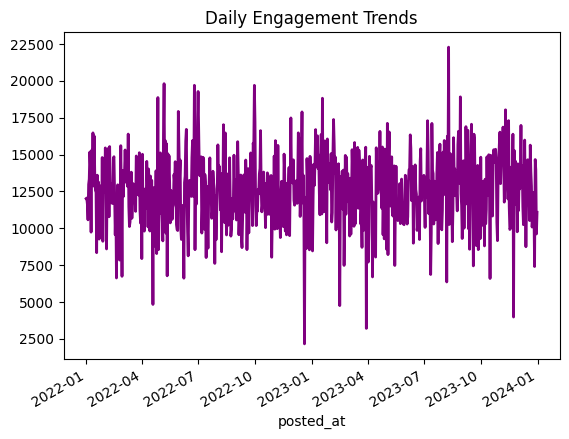

In [ ]:
# line plot -- Daily engagement trends
df.groupby("posted_at")["engagement_score"].mean().plot(color = 'purple', linewidth = 2)
plt.title("Daily Engagement Trends")
plt.show()

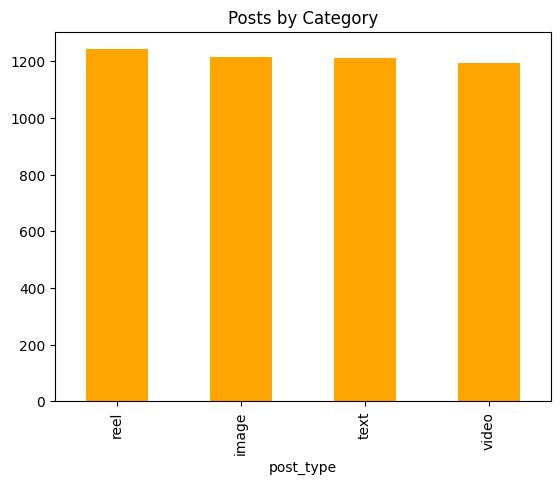

In [ ]:
# Bar Chart -- post by category
df['post_type'].value_counts().plot(kind='bar', color = "orange",)
plt.title("Posts by Category")
plt.show()

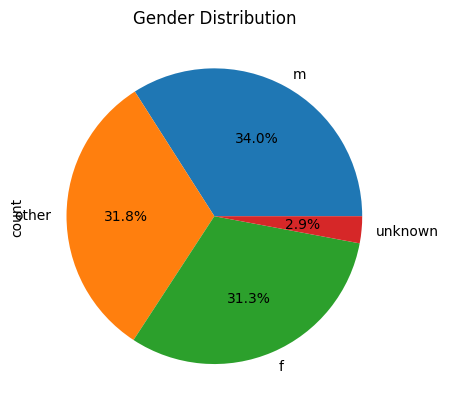

In [ ]:
# pie chart -- gender distribution
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

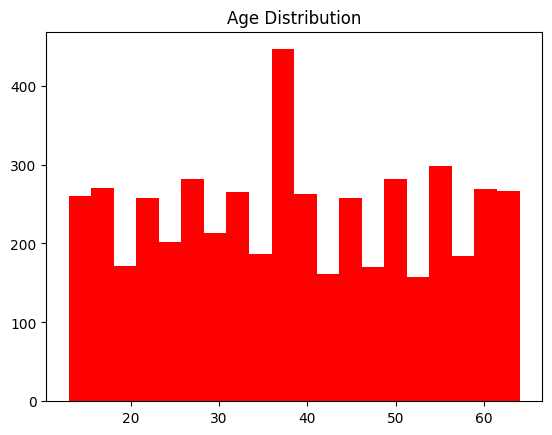

In [ ]:
# Histogram -- age
plt.hist(df['age'], bins=20, color = "red")
plt.title("Age Distribution")
plt.show()

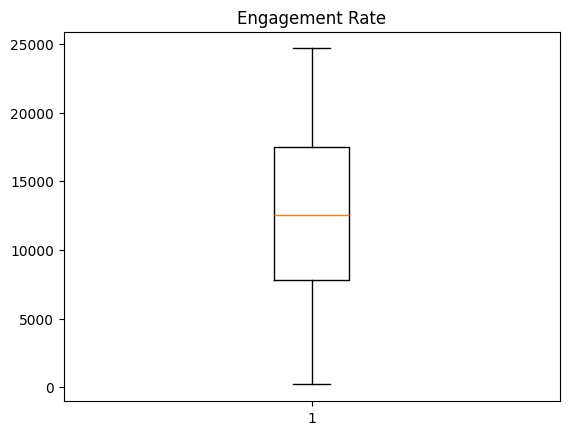

In [ ]:
# Box plot -- engagement rate
plt.boxplot(df["engagement_score"])
plt.title("Engagement Rate")
plt.show()

**(ii) Seaborn**


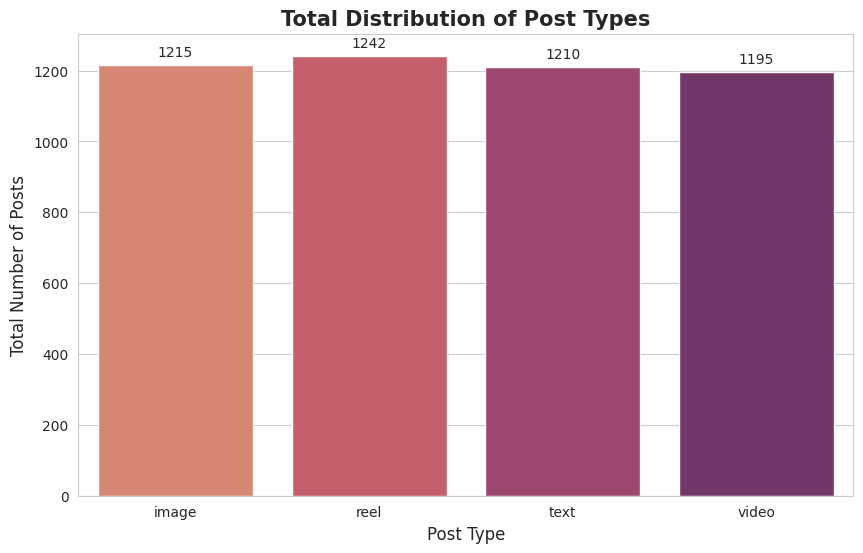

In [ ]:
# count plot -- post type
import seaborn as sns
# Setting a clean background style
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Creating the count plot
# 'palette' options: 'viridis', 'plasma', 'flare', 'crest', 'magma'

ax = sns.countplot(data=df, x='post_type', hue = 'post_type', palette='flare', legend = False)

# Adding labels and title
plt.title('Total Distribution of Post Types', fontsize=15, fontweight='bold')
plt.xlabel('Post Type', fontsize=12)
plt.ylabel('Total Number of Posts', fontsize=12)
# Keep the annotations (optional but recommended)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

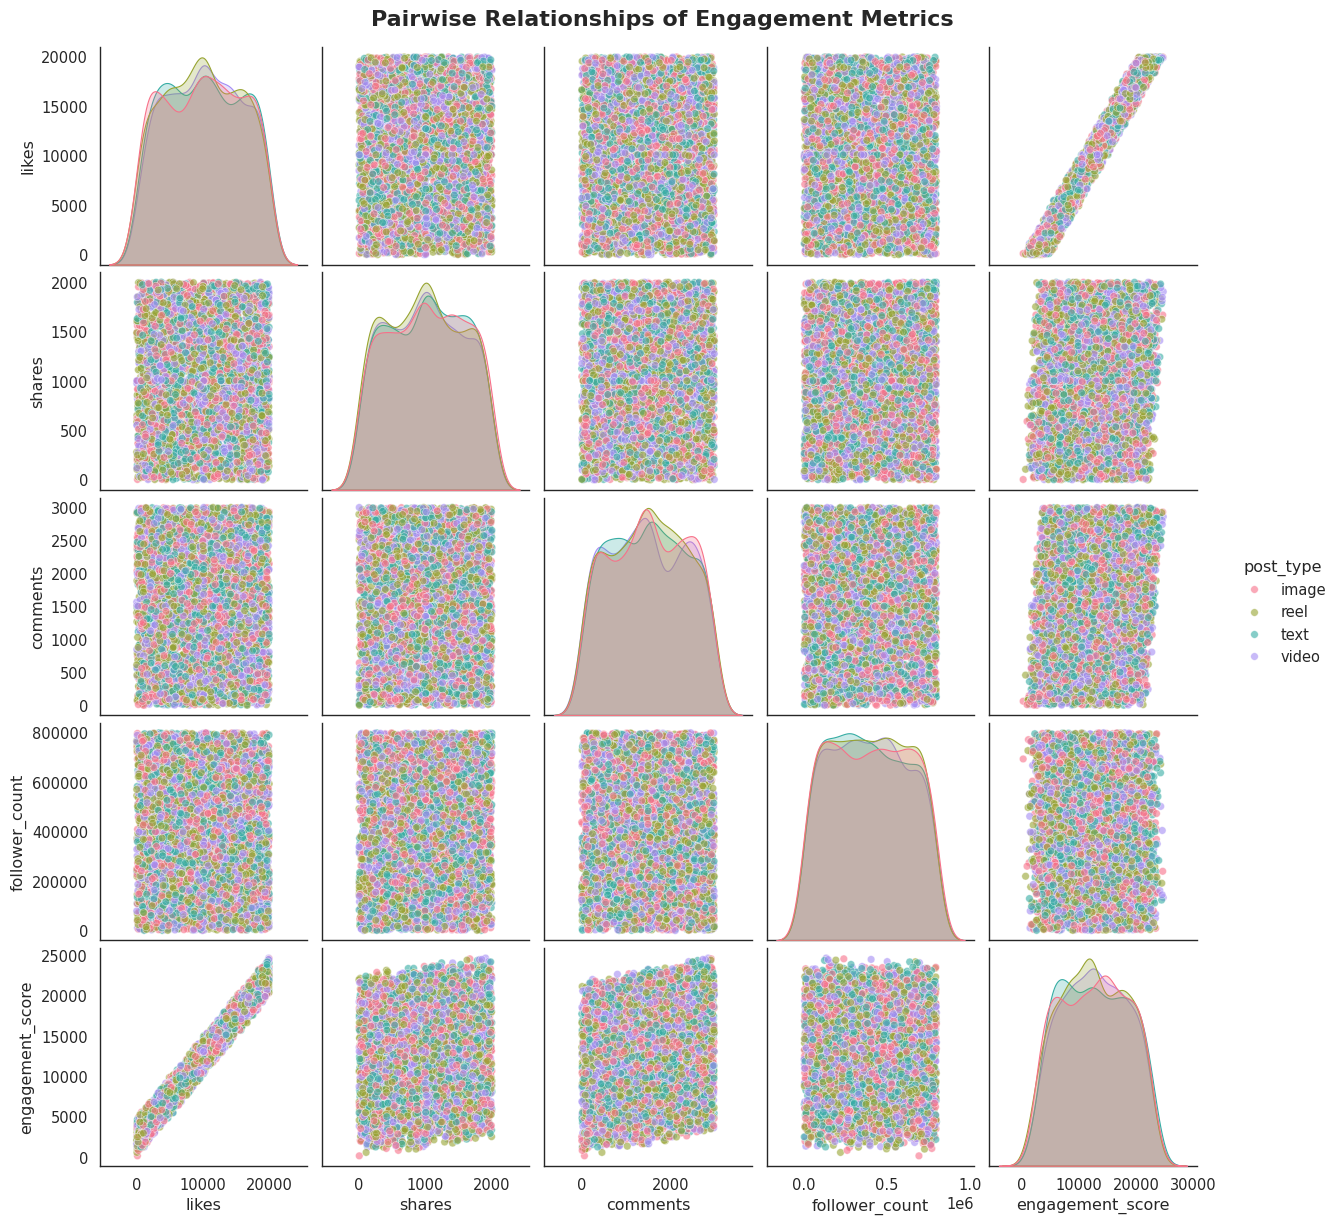

In [ ]:
# pair plot -- numeric  features
# 1.  select the numeric feature
numeric_col = ["likes", "shares", "comments", "follower_count", "engagement_score"]
sns.set_style("white")
sns.set_context("paper", font_scale=1.2)
pair_plot = sns.pairplot(
    df[numeric_col + ['post_type']],
    hue='post_type',
    palette='husl',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30})
# 3. Final touches
plt.subplots_adjust(top=0.95)
pair_plot.fig.suptitle('Pairwise Relationships of Engagement Metrics', fontsize=16, fontweight='bold')
plt.show()

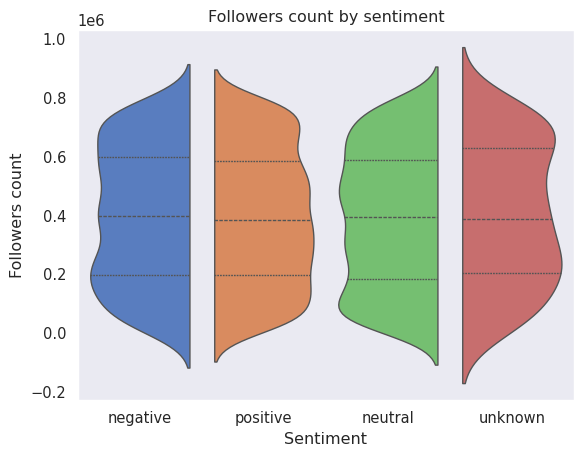

In [ ]:
# Violin plot -- followers vs sentiments
sns.set_style("dark")
sns.violinplot(data=df, x= "sentiment", y="follower_count", hue = "sentiment", palette ="muted", split = True, inner = "quartile", legend = False)
plt.xlabel("Sentiment")
plt.ylabel("Followers count")
plt.title("Followers count by sentiment")
plt.show()

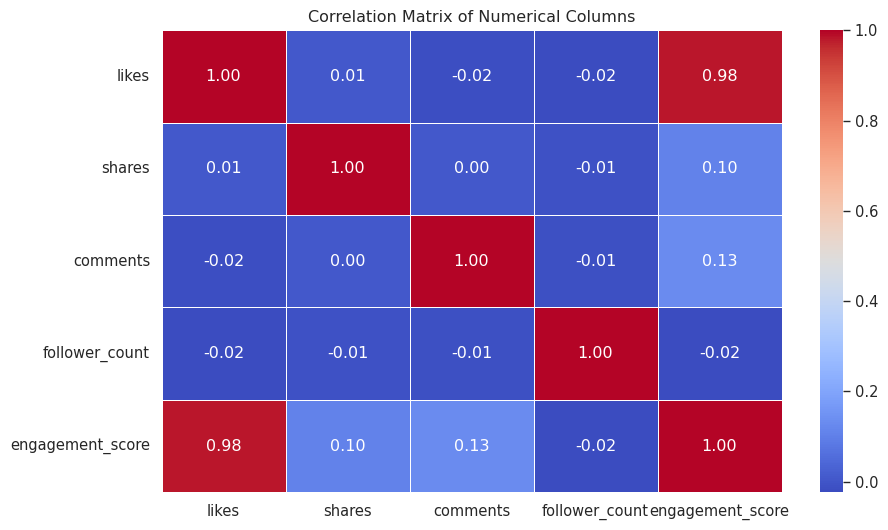

In [ ]:
# 1. Calculate the correlation FIRST
# Use .corr() to turn your data into a correlation matrix
cor_matrix = df[["likes", "shares", "comments", "follower_count", "engagement_score"]].corr()

plt.figure(figsize=(10,6))

# 2. Fix the spelling of 'coolwarm'
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Numerical Columns")
plt.show()

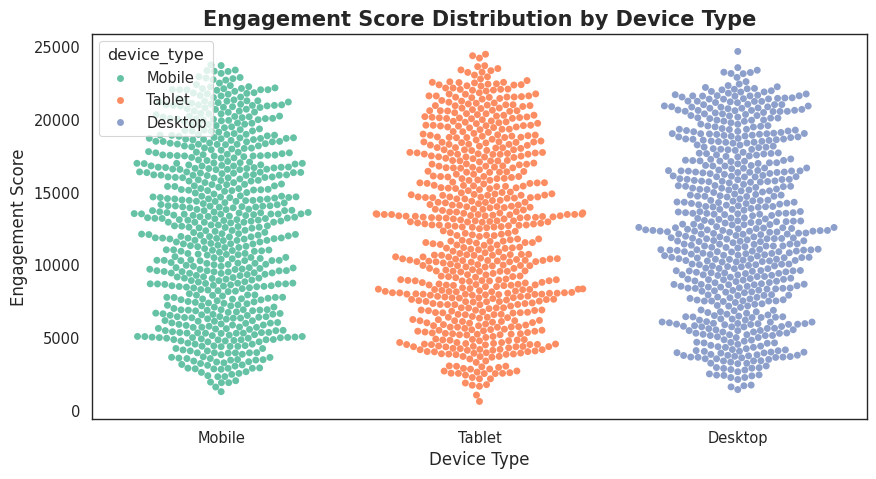

In [ ]:
# Swarm plot -- engagement Vs device
plt.figure(figsize =(10,5))

sns.set_style("white")
sns.swarmplot(data=df.sample(2000), x = "device_type", y ="engagement_score", hue ="device_type", palette = "Set2", size =5, legend = True)
plt.title('Engagement Score Distribution by Device Type', fontsize=15, fontweight='bold')
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)

plt.show()

In [ ]:
import plotly.express as px

# Grouping data by date
daily_data = df.groupby('posted_at')['engagement_score'].mean().reset_index()

fig_line = px.line(daily_data, x='posted_at', y='engagement_score',
                  title='Interactive Daily Engagement Trend',
                  labels={'engagement_score': 'Avg Engagement', 'post_date': 'Date'},
                  template='plotly_white')

fig_line.show()